In [7]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data", header = None)
X = df.iloc[:,2:].values
Y = df.iloc[:,1].values

le = LabelEncoder()

Y = le.fit_transform(Y)

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, stratify= Y,  random_state= 1)




In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA
import numpy as np
kfld = StratifiedKFold(n_splits= 10).split(X_train, Y_train)


pprs = make_pipeline(StandardScaler(), PCA(n_components= 2), LinearRegression())

scores = []

for k, (train, test) in enumerate(kfld):
    pprs.fit(X_train[train],Y_train[train])
    score = pprs.score(X_train[test], Y_train[test])
    scores.append(score)

    print(f"fold is {k +1}")
    print(f"The data is in Y: X {np.bincount(Y_train[train])}")
    print(f"The accuacy score is {score}")


mean_accc = np.mean(scores)
std_acc = np.std(scores)
print(f"The mean accuracy score is : {mean_accc:.3f} +/-  {std_acc}")



fold is 1
The data is in Y: X [256 153]
The accuacy score is 0.6112875546713537
fold is 2
The data is in Y: X [256 153]
The accuacy score is 0.4548846694192231
fold is 3
The data is in Y: X [256 153]
The accuacy score is 0.6313111115248351
fold is 4
The data is in Y: X [256 153]
The accuacy score is 0.7403456707901954
fold is 5
The data is in Y: X [256 153]
The accuacy score is 0.5183878176757455
fold is 6
The data is in Y: X [257 153]
The accuacy score is 0.7014148475649864
fold is 7
The data is in Y: X [257 153]
The accuacy score is 0.7477038272065883
fold is 8
The data is in Y: X [257 153]
The accuacy score is 0.6325991935450734
fold is 9
The data is in Y: X [257 153]
The accuacy score is 0.6610097491381404
fold is 10
The data is in Y: X [257 153]
The accuacy score is 0.6930122074497955
The mean accuracy score is : 0.639 +/-  0.0887120439581184


However the SKLEARN ALSO HAS AUTO KFOLD as shown below

In [9]:
from sklearn.model_selection import cross_val_score

npe = cross_val_score(estimator= pprs, X= X_train, y= Y_train, cv = 10, n_jobs= 1)

print(f"Accuracy score is {(npe)}")

print(f"The mean score is {np.mean(npe)} but std dev = {np.std(npe)}")

Accuracy score is [0.59662243 0.43089435 0.67613174 0.7283297  0.53518653 0.61803381
 0.80471002 0.5957324  0.66241484 0.68093027]
The mean score is 0.6328986083770335 but std dev = 0.09846076818449534


# Debugging algorithms with learning and validation curves
Using the learning curve function from scikit-learn to evaluate the model:

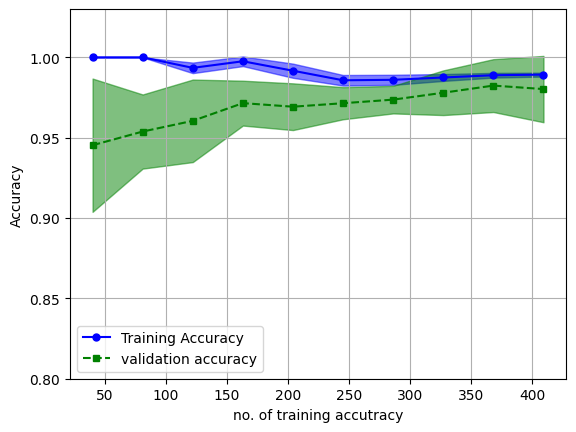

In [10]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression
pipe_lre =  make_pipeline(StandardScaler(), LogisticRegression(penalty= 'l2', max_iter=10000))

train_sizes, train_score, test_score = learning_curve(estimator= pipe_lre, X = X_train, y = Y_train, train_sizes= np.linspace(0.1,1.0,10), cv = 10, n_jobs= 1)

train_mean = np.mean(train_score,axis=1) #mean per each row
train_sd = np.std(train_score, axis= 1)

test_mean = np.mean(test_score,axis= 1)
test_std =np.std(test_score, axis = 1)

plt.plot(train_sizes, train_mean, color = 'blue', marker = 'o', markersize =5, label = 'Training Accuracy')

plt.fill_between(train_sizes, train_mean + train_sd, train_mean - train_sd, alpha = 0.5, color = 'blue')


plt.plot(train_sizes, test_mean, color = 'green',linestyle = '--', marker = 's', markersize = 5, label = "validation accuracy")

plt.fill_between(train_sizes, test_mean + test_std, test_mean - test_std, alpha = 0.5, color = 'green')


plt.grid()
plt.xlabel("no. of training accutracy")
plt.ylabel("Accuracy")
plt.legend(loc = 'best')
plt.ylim([0.8,1.03])
plt.show()





# Adrreshing Overfitting and underfitting with validation curve

(0.8, 1.0)

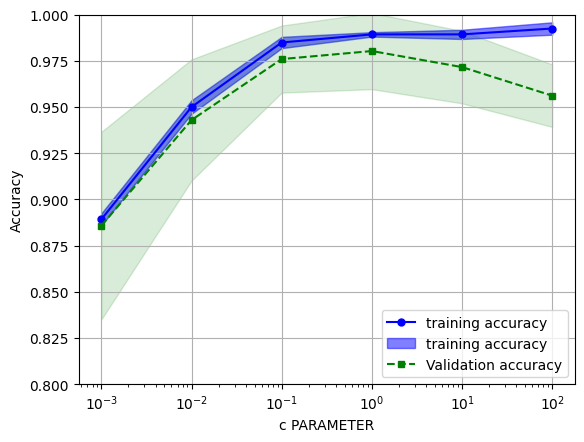

In [11]:
from sklearn.model_selection import validation_curve

param_range = [0.001,0.01,0.1,1.0,10.0,100.0]  # C to vary with respect to logistic regresiion

train_score, test_score = validation_curve(estimator= pipe_lre, X= X_train, y= Y_train, param_name= "logisticregression__C", param_range= param_range, cv= 10)

train_mean = np.mean(train_score, axis = 1)
train_std = np.std(train_score, axis = 1)

test_mean =  np.mean(test_score, axis = 1)

test_std = np.std(test_score, axis = 1)

plt.plot(param_range,train_mean, color = 'blue', marker= 'o', markersize= 5, label = "training accuracy" )

plt.fill_between(param_range, train_mean + train_std, train_mean - train_std , color = 'blue', alpha = 0.5 , label = "training accuracy" )

plt.plot(param_range, test_mean, color='green', linestyle='--', marker='s', markersize=5,  label='Validation accuracy')
plt.fill_between(param_range, test_mean + test_std,test_mean - test_std, alpha=0.15, color='green')

plt.grid()

plt.xscale('log')
plt.legend(loc = 'best')

plt.xlabel("c PARAMETER")

plt.ylabel("Accuracy")
plt.ylim([0.8,1.0])


# Fine-tuning machine learning models via grid search

 grid search help to improve the performance of a model by finding the optimal combination of hyperparameter values.
 # Tuning hyperparameters via grid search

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
pip_vs =  make_pipeline(StandardScaler(), SVC(random_state= 23))

param_range = [0.0001, 0.001, 0.01, 0.1,1,10,100,1000]

param_grid = [{'svc__C': param_range, 'svc__kernel':['linear']}, {'svc__C': param_range, 'svc__gamma': param_range, 'svc__kernel': ['rbf']}]


#GridSearchCV will:
# - Check all the linear kernel options (only varying C).
#- Check all the RBF kernel options (varying both C and gamma).
#- Compare them using cross-validation.
#- Finally, pick whichever kernel + parameter combo gives the best accuracy.

gd = GridSearchCV(estimator= pip_vs, param_grid= param_grid, cv= 10, n_jobs= -1,  scoring= 'accuracy', refit = True)

gd = gd.fit(X_train, Y_train)

print(gd.best_params_)
print(gd.best_score_)

clf = gd.best_estimator_
clf.fit(X_train, Y_train)

print(f'test accuracy: {clf.score(X_test, Y_test):.3f}')



{'svc__C': 100, 'svc__gamma': 0.001, 'svc__kernel': 'rbf'}
0.9846859903381642
test accuracy: 0.974


# Exploring Hyperparameters with randomized Search

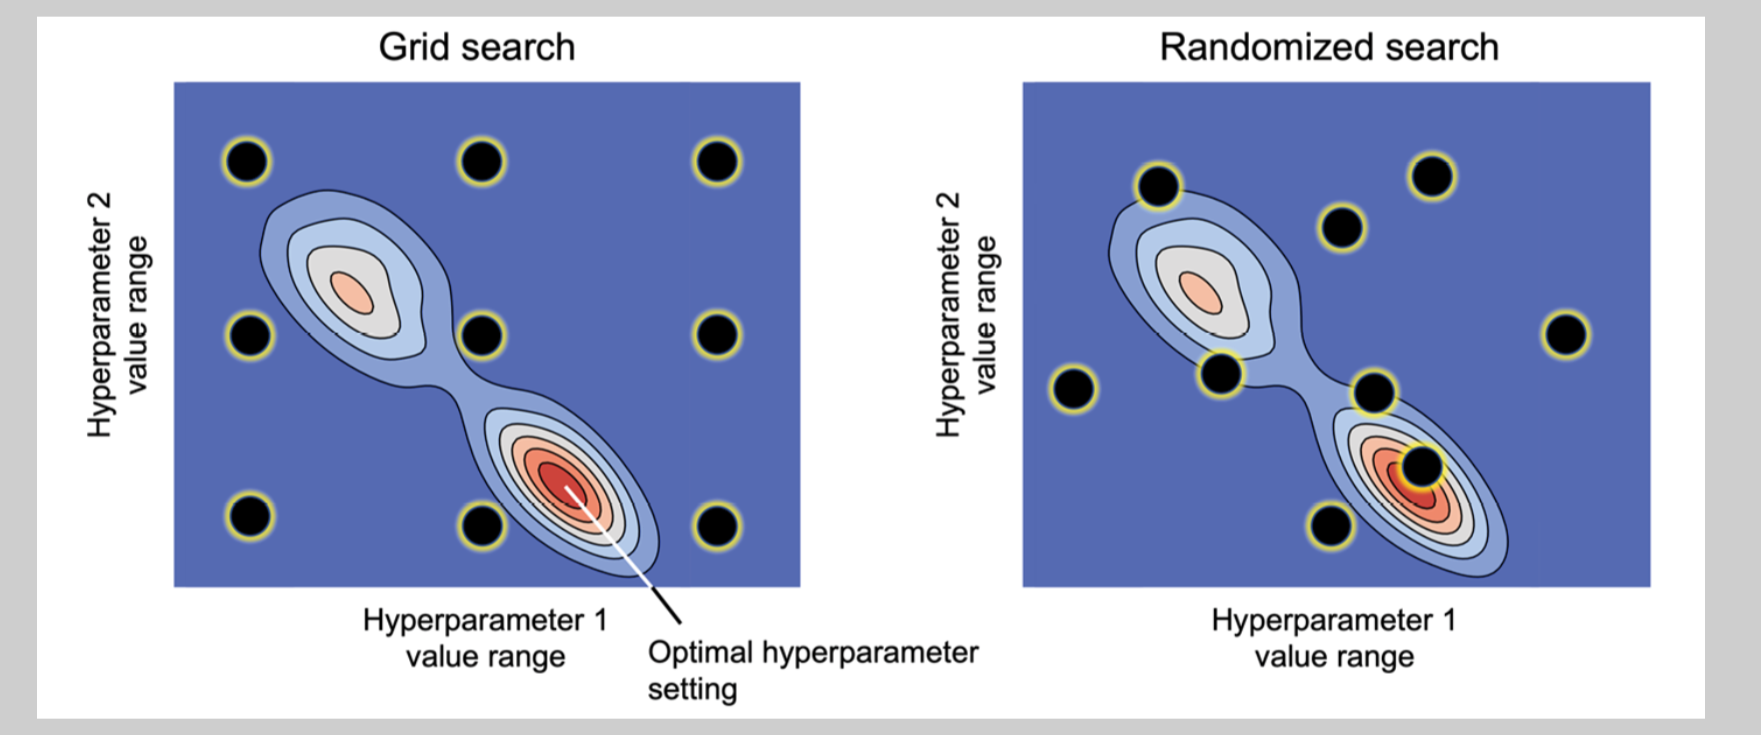
A comparison of grid search and randomized search for sampling nine different hyperparameter configurations each



In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats
pipe_svc = make_pipeline(StandardScaler(), SVC(random_state= 21))


one_param_range = scipy.stats.loguniform(0.0001, 1000.0) # picks random but of unifromit numbers in between 
param_grd = [{'svc__C': one_param_range, 'svc__kernel': ['linear']}, {'svc__C': one_param_range, 'svc__gamma': one_param_range, 'svc__kernel': ['rbf']}]

rdm = RandomizedSearchCV(estimator = pipe_svc, param_distributions = param_grd, scoring = 'accuracy', refit = True, n_iter = 20, cv = 10, random_state = 1, n_jobs = -1)

rs = rdm.fit(X_train, Y_train)
print(rs.best_score_)
print(rs.best_params_)

0.9780676328502416
{'svc__C': np.float64(0.05971247755848463), 'svc__kernel': 'linear'}


# HalvingRandomSearchCV
it makes finding suitable hyperparameter configurations more efficient. procedure:
1. Draw a large set of candidate configurations via random sampling
2. Train the models with limited resources, for example, a small subset of the training data (as opposed to using the entire training set)
3. Discard the bottom 50 percent based on predictive performance
4. Go back to step 2 with an increased amount of available resources